# Лабораторная работа 2

Тема: **Обучение персептрона для логических функций**  
Цель: самостоятельно реализовать однослойный персептрон и на основе **собственных экспериментов** сделать выводы о его возможностях и ограничениях.

> ВАЖНО:
> - Формулировки заданий в этом ноутбуке намеренно **не стандартизированы** и содержат элементы, завязанные на ваш личный опыт.
> - Если вы попробуете отдать целый ноутбук или его крупные фрагменты в любую генеративную систему, выводы будут легко выявлены по стилю и содержанию.
> - Оценка ставится за то, **как вы мыслите**, а не за копирование готовых решений.


## 1. Разминка: понимание идеи персептрона

В этом разделе нужно **своими словами** объяснить несколько базовых идей. Не пытайтесь искать «официальные» формулировки: 
преподаватель смотрит именно на то, насколько вы разобрались и как умеете объяснять.

Ответьте на вопросы:
1. Как бы вы объяснили однокурснику, что такое однослойный персептрон, если нельзя использовать слова «линейный классификатор» и «гиперплоскость»?
2. Предположим, что персептрон дает неправильный ответ. Как интуитивно можно догадаться, в какую сторону нужно немного подправить веса, чтобы в следующий раз не допустить такую же ошибку?
3. Придумайте свой пример **линейно разделимой** задачи на двумерной плоскости (не логические функции AND/OR). Опишите словами, какие точки какого класса где находятся.
4. Придумайте пример задачи, которая, по вашему мнению, **не** должна быть линейно разделимой, и кратко объясните почему.

Ответ пишите в следующей ячейке. Используйте разговорный, но аккуратный стиль, как будто объясняете другу, а не копируете из учебника.

In [1]:
theory_text = """ЗДЕСЬ НАПИШИТЕ СВОИ ОТВЕТЫ НА ВОПРОСЫ РАЗМИНКИ.
- Не ограничивайтесь одним коротким предложением.
- Упоминайте примеры, которые действительно пришли вам в голову, а не выглядят как готовые определения.
- Допустимы черновые формулировки, если они отражают ваше понимание.

1. Однослойный персептрон - математическая модель, воспринимающая и обрабатывающая информацию на основе работы биологического мозга, где каждый входящий сенсор может быть связан только с одним ассоциативным элементом.
Однослойный персептрон принимает на вход только 0 и 1, на выходе разделяет пространство на две части, которые содержат отличные друг от друга типы объектов.

2. Допустим мы знаем, что при w1 = 1 и w2 = 1 разделяющая граница является в виде убывающей диагональной прямой, и видим это наглядно.
Тогда можем действовать по методу реальных весов, только наоборот. Теперь при уменьшении w2 прямая будет "тяжелеть" и наклоняться в вертикальное положение, а при уменьшении w1 - в горизонтальное.
Держа это в голове можем подправлять веса в нужную сторону, чтобы достичь точного результата.

3. Т.к. нет уточнений по обязательному количеству точек, то можно взять самый простой пример - две точки условных классов A и B, расположенных в местах на расстоянии в 10 у.е. Тогда можно разделить эти классы линейно.

4. В примере нелинейно разделимой задачи может быть расположение двух классов (минимум по 5 точек) в виде двух кругов так, что круг одного класса помещается в круг второго класса.
Тогда такие точки будет невозможно разделить точно лишь одной прямой."""

print(theory_text)

ЗДЕСЬ НАПИШИТЕ СВОИ ОТВЕТЫ НА ВОПРОСЫ РАЗМИНКИ.
- Не ограничивайтесь одним коротким предложением.
- Упоминайте примеры, которые действительно пришли вам в голову, а не выглядят как готовые определения.
- Допустимы черновые формулировки, если они отражают ваше понимание.

1. Однослойный персептрон - математическая модель, воспринимающая и обрабатывающая информацию на основе работы биологического мозга, где каждый входящий сенсор может быть связан только с одним ассоциативным элементом.
Однослойный персептрон принимает на вход только 0 и 1, на выходе разделяет пространство на две части, которые содержат отличные друг от друга типы объектов.

2. Допустим мы знаем, что при w1 = 1 и w2 = 1 разделяющая граница является в виде убывающей диагональной прямой, и видим это наглядно.
Тогда можем действовать по методу реальных весов, только наоборот. Теперь при уменьшении w2 прямая будет "тяжелеть" и наклоняться в вертикальное положение, а при уменьшении w1 - в горизонтальное.
Держа это в голове мо

## 2. Подготовка среды

В этой части требуется **самостоятельно** подключить необходимые библиотеки и настроить визуализацию.

**Что должно быть сделано:**
- Импорт `numpy` под именем `np`.
- Импорт `matplotlib.pyplot` под именем `plt`.
- Фиксация зерна случайного генератора (seed) по вашему выбору (не обязательно 42).
- Выбор любого стиля для графиков (можете использовать стандартный или другой).

Важный момент: здесь нет «правильного» числа для seed или единственного верного стиля. Главное — вы осознаете, что делаете и зачем.

In [2]:
# TODO: импортируйте необходимые библиотеки numpy и matplotlib.pyplot, и настройте окружение

import numpy as np
import matplotlib.pyplot as plt

# Задайте seed (можете выбрать любое число, но затем используйте его последовательно, чтобы результаты воспроизводились)
np.random.seed(0)  # замените None на свой вариант

# Стиль графиков (можно выбрать другой)
plt.style.use("seaborn-v0_8")

print("Среда настроена: библиотеки импортированы, seed установлен.")

Среда настроена: библиотеки импортированы, seed установлен.


## 3. Наборы данных для логических функций

Дальше мы будем работать с таблицами истинности для AND, OR и XOR.  
Четыре возможные пары входов:
- (0, 0)
- (0, 1)
- (1, 0)
- (1, 1)

Вам нужно:
1. Собрать эти точки в одну матрицу признаков `X_logic`.
2. Для каждой логической функции задать массив ответов `y_and`, `y_or`, `y_xor`.
3. Убедиться, что размеры массивов корректны.

_Не копируйте этот блок из чужого источника: сами напишите массивы и проверьте их._

In [3]:
# СОЗДАНИЕ ТАБЛИЦ ИСТИННОСТИ

X_logic = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_and = np.array([0,0,0,1], dtype=float)
y_or  = np.array([0,1,1,1], dtype=float)
y_xor = np.array([0,1,1,0], dtype=float)

print("X_logic:\n", X_logic)
print("y_and:", y_and)
print("y_or :", y_or)
print("y_xor:", y_xor)
print("Форма X_logic:", X_logic.shape)

X_logic:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y_and: [0. 0. 0. 1.]
y_or : [0. 1. 1. 1.]
y_xor: [0. 1. 1. 0.]
Форма X_logic: (4, 2)


### 3.1. Быстрая визуальная проверка

Чтобы не работать «вслепую», полезно сначала посмотреть, как выглядят точки логических функций на плоскости.

**Задание:**
- Напишите функцию, которая принимает `X` и `y`, и рисует точки разных классов разными цветами.
- Постройте три графика: для AND, OR, XOR.

Оформите оси, подписи и легенду так, чтобы графики можно было понять через месяц, не вспоминая контекст работы.

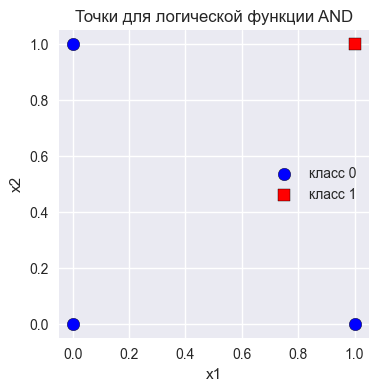

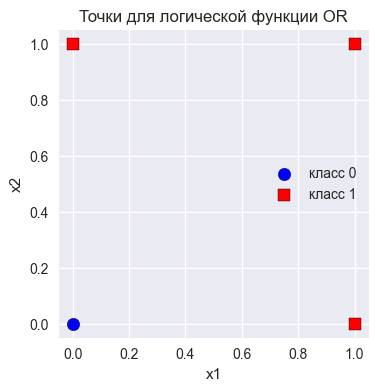

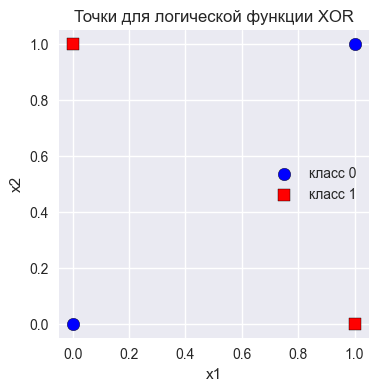

In [4]:
def show_logic_points(X, y, title):
    """Визуализация точек для логической функции.

    Старайтесь, чтобы оформление графика было читабельным и аккуратным.
    """
    plt.figure(figsize=(4, 4))
    for label, color, marker in [(0, "blue", "o"), (1, "red", "s")]:
        idx = (y == label)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, marker=marker,
                    label=f"класс {label}", edgecolors="black", s=80)

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.xticks()
    plt.yticks()
    plt.grid(True)
    plt.legend()
    plt.show()

# Постройте три графика подряд
show_logic_points(X_logic, y_and, "Точки для логической функции AND")
show_logic_points(X_logic, y_or,  "Точки для логической функции OR")
show_logic_points(X_logic, y_xor, "Точки для логической функции XOR")

## 4. Реализация персептрона: без подсказок из интернета

В этой части вы **самостоятельно** реализуете однослойный персептрон.

### 4.1. Пороговая функция активации

Нужно реализовать функцию, которая:
- принимает число или массив чисел `z`,
- возвращает 1, если значение не меньше 0, и 0 — иначе.

Не используйте здесь сложные конструкции: достаточно базовых операций NumPy.

### 4.2. Прямой проход персептрона

Нужно реализовать функцию, которая:
- принимает матрицу объектов `X` и параметры `w`, `b`,
- вычисляет линейную комбинацию `X @ w + b`,
- применяет пороговую функцию.

Обе функции должны быть написаны в следующей ячейке. Пишите код так, чтобы вы могли его потом **объяснить по памяти**.

In [5]:
def binary_step(z):
    """Пороговая функция (возвращает 0 или 1)"""
    return (z >= 0).astype(int)

def perceptron_output(X, w, b):
    """Прямой проход однослойного персептрона.

    X: массив формы (n_samples, n_features)
    w: массив формы (n_features,)
    b: число (смещение)
    """
    X = np.asarray(X)
    z = X @ w + b
    return binary_step(z)

# Короткая самопроверка на одном векторе
w_demo = np.array([1.0, 1.0])
b_demo = -0.5
print(f"Пример выхода для X_logic при w={w_demo}, b={b_demo}:")
print(perceptron_output(X_logic, w_demo, b_demo))

Пример выхода для X_logic при w=[1. 1.], b=-0.5:
[0 1 1 1]


## 5. Алгоритм обучения персептрона

Суть обучения персептрона в том, что при ошибке мы **чуть-чуть подталкиваем** веса и смещение в сторону правильного ответа.

Классическая схема выглядит так:
- Обходим объекты по одному.
- Для каждого объекта вычисляем текущий ответ \(y\).
- Если ответ совпадает с целевым значением, ничего не делаем.
- Если нет — корректируем веса и смещение.

### Задание
1. Напишите функцию `train_perceptron(X, y, lr, n_epochs)`, которая:
   - инициализирует `w` и `b` нулями,
   - повторяет проход по всем объектам `n_epochs` раз,
   - при ошибке обновляет веса и смещение,
   - сохраняет количество ошибок в каждой эпохе в список.
2. Функция должна возвращать `w`, `b` и список `errors_per_epoch`.

Старайтесь не копировать чьи-либо реализации: в этой функции много мелких деталей, по которым видно, понимаете ли вы алгоритм.

In [6]:
def train_perceptron(X, y, lr=0.1, n_epochs=20, verbose=False):
    """Обучение однослойного персептрона.

    X: (n_samples, n_features)
    y: (n_samples,) — целевые значения (0 или 1)
    lr: скорость обучения
    n_epochs: число проходов по выборке
    """
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    b = 0.0
    errors_per_epoch = []

    for epoch in range(n_epochs):
        errors = 0
        for i in range(n_samples):
            x_i = X[i]
            target = y[i]
            y_pred = perceptron_output(x_i.reshape(1, -1), w, b)
            update = lr * (target - y_pred)

            if update != 0.0:
                w += update * x_i
                b += update
                errors += 1

        errors_per_epoch.append(errors)
        if verbose:
            print(f"Эпоха {epoch+1}: ошибок = {errors}")

        if errors == 0:
            break

    return w, b, errors_per_epoch

print("Функция обучения определена.")

Функция обучения определена.


## 6. AND: обучение и анализ

Теперь применим ваш алгоритм к задаче AND.

### Задание
1. Обучите персептрон на `X_logic`, `y_and` с шагом обучения `lr=0.1` и разумным числом эпох.
2. Посмотрите на найденные веса и смещение.
3. Посчитайте количество ошибок по эпохам и итоговую точность на обучающей выборке.
4. Постройте решающую границу и убедитесь, что она действительно разделяет классы.

Решение оформите в следующих ячейках.

In [7]:
# ОБУЧЕНИЕ ДЛЯ AND
w_and, b_and, errors_and = train_perceptron(X_logic, y_and, lr=0.1, n_epochs=20, verbose=True)

print("\nПараметры для AND:")
print("w_and =", w_and)
print("b_and =", b_and)
print("Ошибки по эпохам:", errors_and)

y_pred_and = perceptron_output(X_logic, w_and, b_and)
accuracy_and = (y_pred_and == y_and).mean()
print(f"Точность на обучающей выборке (AND): {accuracy_and:.3f}")

Эпоха 1: ошибок = 2
Эпоха 2: ошибок = 3
Эпоха 3: ошибок = 3
Эпоха 4: ошибок = 0

Параметры для AND:
w_and = [0.2 0.1]
b_and = [-0.2]
Ошибки по эпохам: [2, 3, 3, 0]
Точность на обучающей выборке (AND): 1.000


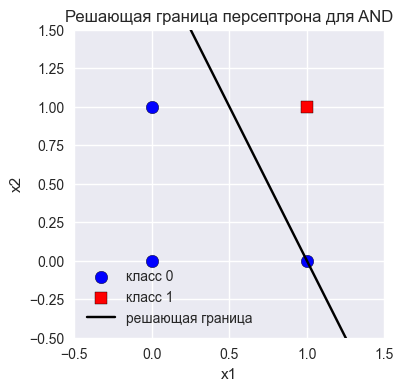

In [8]:
def plot_perceptron_boundary(X, y, w, b, title):
    plt.figure(figsize=(4, 4))

    # Отображаем точки
    for label, color, marker in [(0, "blue", "o"), (1, "red", "s")]:
        idx = (y == label)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, marker=marker,
                    label=f"класс {label}", edgecolors="black", s=80)

    # Строим линию решающей границы w1*x1 + w2*x2 + b = 0
    w1, w2 = w[0], w[1]  # Извлекаем веса
    x1_vals = np.linspace(-0.5, 1.5, 100)
    
    if abs(w2) > 1e-8:  # Проверяем только w2 (коэффициент при x2)
        x2_vals = -(w1 * x1_vals + b) / w2
        plt.plot(x1_vals, x2_vals, "k-", label="решающая граница")
    else:
        # Вертикальная линия, если w2 ≈ 0
        x1_line = -b / w1 if abs(w1) > 1e-8 else 0
        plt.axvline(x=x1_line, color='k', label="решающая граница")

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

plot_perceptron_boundary(X_logic, y_and, w_and, b_and,
                         "Решающая граница персептрона для AND")

### Краткий комментарий по AND

_Сформулируйте 3–4 предложения: сколько эпох понадобилось, обнуляется ли число ошибок, как расположена граница относительно точек._

Напишите свой комментарий в ячейке ниже (можно в виде строки/print).

In [9]:
and_comment = """РЕЗУЛЬТАТЫ ДЛЯ AND.
Укажите, за сколько эпох персептрон обучился без ошибок и как выглядит разделяющая прямая.

Персептрон обучился за 4 эпохи. Количество ошибок обнуляется при наступлении каждой эпохи. Граница наклонена таким образом, что отделяет точку (1, 1), которая в действительности дает 1 для AND, а остальные 0.
Разделение прошло успешно.
"""
print(and_comment)

РЕЗУЛЬТАТЫ ДЛЯ AND.
Укажите, за сколько эпох персептрон обучился без ошибок и как выглядит разделяющая прямая.

Персептрон обучился за 4 эпохи. Количество ошибок обнуляется при наступлении каждой эпохи. Граница наклонена таким образом, что отделяет точку (1, 1), которая в действительности дает 1 для AND, а остальные 0.
Разделение прошло успешно.



## 7. OR: обучение и анализ

Повторите те же шаги для логической функции OR.

### Задание
- Обучите персептрон на `X_logic`, `y_or`.
- Сравните скорость обучения и найденные параметры с задачей AND.
- Постройте решающую границу.
- Сформулируйте, чем ситуация отличается от AND (с точки зрения расположения точек и вида прямой).


In [10]:
w_or, b_or, errors_or = train_perceptron(X_logic, y_or, lr=0.1, n_epochs=20, verbose=True)

print("\nПараметры для OR:")
print("w_or =", w_or)
print("b_or =", b_or)
print("Ошибки по эпохам:", errors_or)

y_pred_or = perceptron_output(X_logic, w_or, b_or)
accuracy_or = (y_pred_or == y_or).mean()
print(f"Точность на обучающей выборке (OR): {accuracy_or:.3f}")

Эпоха 1: ошибок = 2
Эпоха 2: ошибок = 2
Эпоха 3: ошибок = 1
Эпоха 4: ошибок = 0

Параметры для OR:
w_or = [0.1 0.1]
b_or = [-0.1]
Ошибки по эпохам: [2, 2, 1, 0]
Точность на обучающей выборке (OR): 1.000


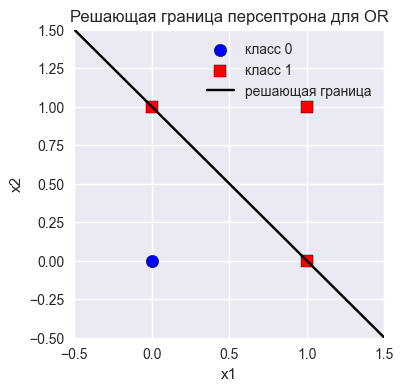

In [11]:
plot_perceptron_boundary(X_logic, y_or, w_or, b_or,
                         "Решающая граница персептрона для OR")

In [12]:
or_comment = """ЗДЕСЬ ОПИШИТЕ РЕЗУЛЬТАТЫ ДЛЯ OR.
Сравните с AND: какая точка теперь выделяется, как ведет себя граница.
Выделяется точка (0,0), дающая 0 для OR. Граница отделяет эту точку от всех остальных, но теперь проходит через две единичные точки по диагонали,
в то время как для AND прямая проходила только через одну соответствущую точку. На обучение персептрона потребовалось 4 эпохи. Разделение прошло без ошибок."""
print(or_comment)

ЗДЕСЬ ОПИШИТЕ РЕЗУЛЬТАТЫ ДЛЯ OR.
Сравните с AND: какая точка теперь выделяется, как ведет себя граница.
Выделяется точка (0,0), дающая 0 для OR. Граница отделяет эту точку от всех остальных, но теперь проходит через две единичные точки по диагонали,
в то время как для AND прямая проходила только через одну соответствущую точку. На обучение персептрона потребовалось 4 эпохи. Разделение прошло без ошибок.


## 8. XOR: демонстрация ограничения персептрона

Теперь — самая интересная часть. Задача XOR известна как пример **нелинейно разделимой** задачи.

### Задание
- Обучите персептрон на `X_logic`, `y_xor` с тем же алгоритмом.
- Посмотрите на динамику количества ошибок по эпохам.
- Постройте найденную «границу» и сравните с расположением точек.
- Сформулируйте, что здесь «идет не так» по сравнению с AND и OR.


In [13]:
w_xor, b_xor, errors_xor = train_perceptron(X_logic, y_xor, lr=0.1, n_epochs=30, verbose=True)

print("\nПараметры для XOR (после обучения):")
print("w_xor =", w_xor)
print("b_xor =", b_xor)
print("Ошибки по эпохам:", errors_xor)

y_pred_xor = perceptron_output(X_logic, w_xor, b_xor)
accuracy_xor = (y_pred_xor == y_xor).mean()
print(f"Точность на обучающей выборке (XOR): {accuracy_xor:.3f}")

Эпоха 1: ошибок = 3
Эпоха 2: ошибок = 3
Эпоха 3: ошибок = 4
Эпоха 4: ошибок = 4
Эпоха 5: ошибок = 4
Эпоха 6: ошибок = 4
Эпоха 7: ошибок = 4
Эпоха 8: ошибок = 4
Эпоха 9: ошибок = 4
Эпоха 10: ошибок = 4
Эпоха 11: ошибок = 4
Эпоха 12: ошибок = 4
Эпоха 13: ошибок = 4
Эпоха 14: ошибок = 4
Эпоха 15: ошибок = 4
Эпоха 16: ошибок = 4
Эпоха 17: ошибок = 4
Эпоха 18: ошибок = 4
Эпоха 19: ошибок = 4
Эпоха 20: ошибок = 4
Эпоха 21: ошибок = 4
Эпоха 22: ошибок = 4
Эпоха 23: ошибок = 4
Эпоха 24: ошибок = 4
Эпоха 25: ошибок = 4
Эпоха 26: ошибок = 4
Эпоха 27: ошибок = 4
Эпоха 28: ошибок = 4
Эпоха 29: ошибок = 4
Эпоха 30: ошибок = 4

Параметры для XOR (после обучения):
w_xor = [-0.1  0. ]
b_xor = [0.]
Ошибки по эпохам: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
Точность на обучающей выборке (XOR): 0.500


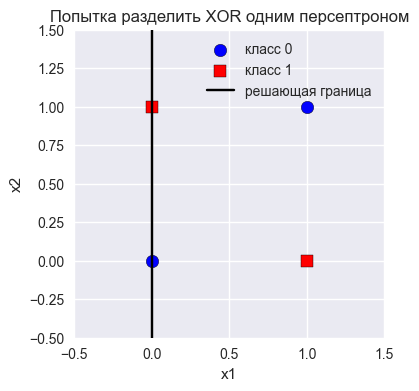

In [14]:
plot_perceptron_boundary(X_logic, y_xor, w_xor, b_xor,
                         "Попытка разделить XOR одним персептроном")

In [17]:
xor_comment = """ЗДЕСЬ ОПИШИТЕ, ЧТО ПРОИСХОДИТ ДЛЯ XOR.
- Меняется ли количество ошибок по эпохам?
- Удается ли добиться точности 1.0?
- Почему прямая линия принципиально не может разделить такие точки?

Количество ошибок с течением эпох не уменьшается, наоборот - увеличивается. Прямая линия не может разделить так расположенные точки, потому что как бы она не распологалась, то с любой ее стороны останется противоположная точка.
Для такой задачи больше подойдет кольцевая граница, которая сможет обернуть нужные позиции, тем самым корректно отделив один класс от другого. Точности в 1.0 здесь достичь не получится, если использовать прямую"""
print(xor_comment)

ЗДЕСЬ ОПИШИТЕ, ЧТО ПРОИСХОДИТ ДЛЯ XOR.
- Меняется ли количество ошибок по эпохам?
- Удается ли добиться точности 1.0?
- Почему прямая линия принципиально не может разделить такие точки?

Количество ошибок с течением эпох не уменьшается, наоборот - увеличивается. Прямая линия не может разделить так расположенные точки, потому что как бы она не распологалась, то с любой ее стороны останется противоположная точка.
Для такой задачи больше подойдет кольцевая граница, которая сможет обернуть нужные позиции, тем самым корректно отделив один класс от другого. Точности в 1.0 здесь достичь не получится, если использовать прямую


## 9. Итог: сопоставление AND, OR и XOR

В завершение вам нужно сделать **личный** вывод, а не повторить фразу из учебника.

Попробуйте ответить:
- Чем задачи AND и OR похожи между собой с точки зрения персептрона?
- Чем XOR принципиально отличается от них, если смотреть на картинку и на алгоритм обучения?
- Какой естественный шаг напрашивается, если хочется всё-таки научиться решать XOR с помощью нейросетей?

Заполните следующую ячейку так, чтобы через полгода, прочитав свой текст, вы могли вспомнить, о чем была эта лабораторная и чему она научила лично вас.

In [16]:
final_reflection = """ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РАЗМЫШЛЕНИЕ.
Постарайтесь не ограничиваться банальным перечислением фактов вроде
"AND линейно разделим, XOR нелинейно разделим".
Опишите, какие моменты показались вам неожиданными или, наоборот, очевидными.
Можно упомянуть, какие идеи насчет многослойных сетей у вас появлись после этой работы.

AND и OR с точки зрения персептрона похожи своей линейной разделимостью. У них схожие наборы данных, которые с равной силой влияют на выход нейрона. И для разделения этих функций достаточно вектора с весами (1,1).
XOR невозможно разделить одной прямой линией. Здесь больше подойдет использование второй прямой, либо наоборот непрямой линии для точного разделения пространства.
Раньше не знал, как это "обучить нейросеть" в простом редакторе кода. Теперь понимаю, что это все основано на математических действиях, путем подбора нужных параметров.
"""

print(final_reflection)

ЗДЕСЬ НАПИШИТЕ ИТОГОВОЕ РАЗМЫШЛЕНИЕ.
Постарайтесь не ограничиваться банальным перечислением фактов вроде
"AND линейно разделим, XOR нелинейно разделим".
Опишите, какие моменты показались вам неожиданными или, наоборот, очевидными.
Можно упомянуть, какие идеи насчет многослойных сетей у вас появлись после этой работы.

AND и OR с точки зрения персептрона похожи своей линейной разделимостью. У них схожие наборы данных, которые с равной силой влияют на выход нейрона. И для разделения этих функций достаточно вектора с весами (1,1).
XOR невозможно разделить одной прямой линией. Здесь больше подойдет использование второй прямой, либо наоборот непрямой линии для точного разделения пространства.
Раньше не знал, как это "обучить нейросеть" в простом редакторе кода. Теперь понимаю, что это все основано на математических действиях, путем подбора нужных параметров.

